# Weighted Note Tables for A Corpus of Pieces



## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import crim_intervals
from crim_intervals import * 
from crim_intervals import main_objs
import crim_intervals.corpus_tools as corpus_tools

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'jupyterlab'

import importlib
import music_utils
importlib.reload(music_utils)
from music_utils import *

import glob as glob

# Display options
pd.set_option("display.float_format", "{:.4f}".format)

## 2a. Exploring Weighted Notes with One Piece

In [2]:
# just ONE piece for testing
chanson_as_corpus =  ['https://crimproject.org/mei/CRIM_Model_0012.mei']
corpus = CorpusBase(chanson_as_corpus)

# get weighted notes
weighted_notes = corpus_note_weights(corpus)
weighted_notes = weighted_notes.rename(columns={'index': 'pitch_class'})
# the pitch_class_order_with_rests is defined in the code base
weighted_notes['pitch_class'] = pd.Categorical(weighted_notes['pitch_class'], categories=pitch_class_order_with_rests, ordered=True)

# Sort the DataFrame
weighted_notes_sorted = weighted_notes.sort_values('pitch_class')
weighted_notes_sorted['pitch_class'] =weighted_notes_sorted['pitch_class'].astype(str)

# Reset the index and correct flat names--the 'standardize note' function is in the code base
weighted_notes_sorted = weighted_notes_sorted.reset_index(drop=True)
weighted_notes_sorted['pitch_class']= weighted_notes_sorted['pitch_class'].map(standardize_note)


# save csv for later use
weighted_notes_sorted.to_csv('full_corpus_note_weights.csv')

# display in descending order of weight
weighted_notes_sorted.sort_values('scaled', ascending=False)

,pitch_class,count,scaled,composer,title
2,D,339.0000,0.2057,Pierre Sandrin,Voulant honneur
7,G,286.5000,0.1738,Pierre Sandrin,Voulant honneur
5,F,215.0000,0.1305,Pierre Sandrin,Voulant honneur
9,Bb,213.0000,0.1292,Pierre Sandrin,Voulant honneur
8,A,211.5000,0.1283,Pierre Sandrin,Voulant honneur
0,C,181.0000,0.1098,Pierre Sandrin,Voulant honneur
10,Rest,96.0000,0.0583,Pierre Sandrin,Voulant honneur
4,E,79.0000,0.0479,Pierre Sandrin,Voulant honneur
6,F#,16.0000,0.0097,Pierre Sandrin,Voulant honneur
1,C#,8.0000,0.0049,Pierre Sandrin,Voulant honneur


## 2b.  Weighted Notes with a Corpus

In [3]:
# set up various 'corpora' of model + mass movements
je_suis = ['https://crimproject.org/mei/CRIM_Model_0009.mei',
       'https://crimproject.org/mei/CRIM_Mass_0006_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0006_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0006_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0006_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0006_5.mei',
          'https://crimproject.org/mei/CRIM_Mass_0007_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0007_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0007_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0007_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0007_5.mei']

vidi_speciosam = ['https://crimproject.org/mei/CRIM_Model_0001.mei',
       'https://crimproject.org/mei/CRIM_Mass_0002_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0002_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0003_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0004_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0005_5.mei']

quo_abiit = ['https://crimproject.org/mei/CRIM_Model_0015.mei',
       'https://crimproject.org/mei/CRIM_Mass_0013_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0013_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0013_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0013_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0013_5.mei']

congratulamini =  ['https://crimproject.org/mei/CRIM_Model_0026.mei',
       'https://crimproject.org/mei/CRIM_Mass_0024_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0024_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0024_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0024_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0024_5.mei']


voulant =  ['https://crimproject.org/mei/CRIM_Model_0012.mei',
       'https://crimproject.org/mei/CRIM_Mass_0010_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0010_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0010_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0010_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0010_5.mei']


veni =  ['https://crimproject.org/mei/CRIM_Model_0019.mei',
       'https://crimproject.org/mei/CRIM_Mass_0019_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0019_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0019_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0019_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0019_5.mei']

ave =  ['https://crimproject.org/mei/CRIM_Model_0008.mei',
       'https://crimproject.org/mei/CRIM_Mass_0005_1.mei',
          'https://crimproject.org/mei/CRIM_Mass_0005_2.mei',
          'https://crimproject.org/mei/CRIM_Mass_0005_3.mei',
          'https://crimproject.org/mei/CRIM_Mass_0005_4.mei',
          'https://crimproject.org/mei/CRIM_Mass_0005_5.mei']

In [4]:
# build the corpus as crim intervals objects
corpus = CorpusBase(voulant)

In [5]:
# now, create the weighted note tables
weighted_notes = corpus_note_weights(corpus)
weighted_notes = weighted_notes.rename(columns={'index': 'pitch_class'})
weighted_notes['pitch_class'] = pd.Categorical(weighted_notes['pitch_class'], categories=pitch_class_order_with_rests, ordered=True)

# Sort the DataFrame
weighted_notes_sorted = weighted_notes.sort_values('pitch_class')
weighted_notes_sorted['pitch_class'] =weighted_notes_sorted['pitch_class'].astype(str)

# Reset the index and correct flat names
weighted_notes_sorted = weighted_notes_sorted.reset_index(drop=True)
weighted_notes_sorted['pitch_class']= weighted_notes_sorted['pitch_class'].map(standardize_note)

# combine composer and title
# weighted_notes_sorted['comp_title'] = weighted_notes_sorted['composer'] + "_" + weighted_notes_sorted['title']
# save
weighted_notes_sorted.to_csv('full_corpus_note_weights.csv')


weighted_notes_sorted.sort_values('scaled', ascending=False)


,pitch_class,count,scaled,composer,title
68,Rest,1054.0000,0.2928,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei
64,Rest,1000.0000,0.2894,Claudin de Sermisy,Missa Voulant honneur: Sanctus
66,Rest,1432.0000,0.2425,Claudin de Sermisy,Missa Voulant honneur: Credo
63,Rest,634.0000,0.2086,Claudin de Sermisy,Missa Voulant honneur: Gloria
44,G,243.0000,0.2080,Claudin de Sermisy,Missa Voulant honneur: Kyrie
...,...,...,...,...,...
8,C#,2.0000,0.0017,Claudin de Sermisy,Missa Voulant honneur: Kyrie
6,C#,4.0000,0.0007,Claudin de Sermisy,Missa Voulant honneur: Credo
61,B,2.0000,0.0007,Claudin de Sermisy,Missa Voulant honneur: Gloria
7,C#,2.0000,0.0006,Claudin de Sermisy,Missa Voulant honneur: Sanctus


## 2c. Radar Plot of Notes

- note that we can choose among three different orderings for the tones in the plot:
- "Fifths", "Thirds", "Diatonic"
- you can also choose to include/exclude rests, and whether to show all possible tones, or just the active ones

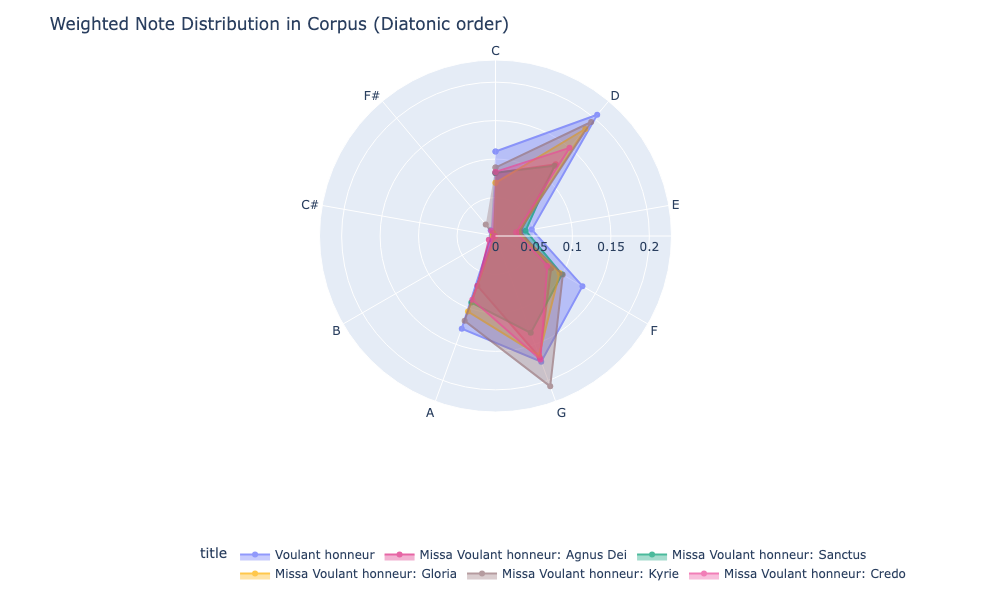

In [10]:
pitch_order = 'Diatonic'
exclude_rests = True
limit_to_active_tones = True

fig = radar_note_plot(weighted_notes_sorted,
                    pitch_class_order=pitch_order,
                    exclude_rests=exclude_rests,
                    limit_to_active=limit_to_active_tones,
                    color_grouping='title'
                    )



## 3a.  Voice Ranges in a Corpus

- note that you can group the results by Final tone, and either for the complete piece or by individual voice parts

In [13]:
# get the notes and durs for tenors, with finals
report_by_final = True
report_by_voice = False

corpus_notes_and_durs = corpus_note_durs(corpus, pitch_class=False)

# standarize pitch names for flats and sharps
corpus_notes_and_durs['Pitch_Class']= corpus_notes_and_durs['Notes'].map(standardize_note)
corpus_notes_and_durs['Composer']= corpus_notes_and_durs['Composer'].fillna('Anon')

len(corpus_notes_and_durs.Title.unique())

# we already created corpus_notes_and_durs above!

# get sum of durations for each voice in each piece--these should be the same!
grouped_notes_durs =  corpus_notes_and_durs.groupby(['Composer', 'Title', 'Voice'])['Durs'].sum().reset_index()
grouped_notes_durs.columns = ['Composer', 'Title', 'Voice', 'TotalDuration']
    
# Merge the original dataframe with the grouped results
corpus_pitch_data = pd.merge(corpus_notes_and_durs, grouped_notes_durs[['Composer', 'Title', 'Voice', 'TotalDuration']], 
                         on=['Composer', 'Title', 'Voice'], how='left')

corpus_pitch_data['Dur_Ratio'] = (corpus_pitch_data['Durs']/corpus_pitch_data['TotalDuration']).round(3)
corpus_pitch_data['Percentage'] = corpus_pitch_data['Dur_Ratio'] * 100
corpus_pitch_data = corpus_pitch_data.groupby(['Composer', 'Title', 'Voice', 'Notes', 'Final'])['Percentage'].sum().reset_index()
corpus_pitch_data

,Composer,Title,Voice,Notes,Final,Percentage
0,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei,1,A4,G,11.3000
1,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei,1,B-4,G,15.7000
2,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei,1,C5,G,3.2000
3,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei,1,D4,G,4.1000
4,Claudin de Sermisy,Missa Voulant honneur: Agnus Dei,1,D5,G,1.3000
...,...,...,...,...,...,...
285,Pierre Sandrin,Voulant honneur,4,E3,G,3.2000
286,Pierre Sandrin,Voulant honneur,4,F3,G,15.4000
287,Pierre Sandrin,Voulant honneur,4,G2,G,11.6000
288,Pierre Sandrin,Voulant honneur,4,G3,G,9.2000


/home/jupyter-rfreedman/tonalities/music_utils.py:318: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/home/jupyter-rfreedman/tonalities/music_utils.py:356: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/home/jupyter-rfreedman/tonalities/music_utils.py:318: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/home/jupyter-rfreedman/tonalities/music_utils.py:356: FutureWarning:

The default of observed=False is deprecated and wi

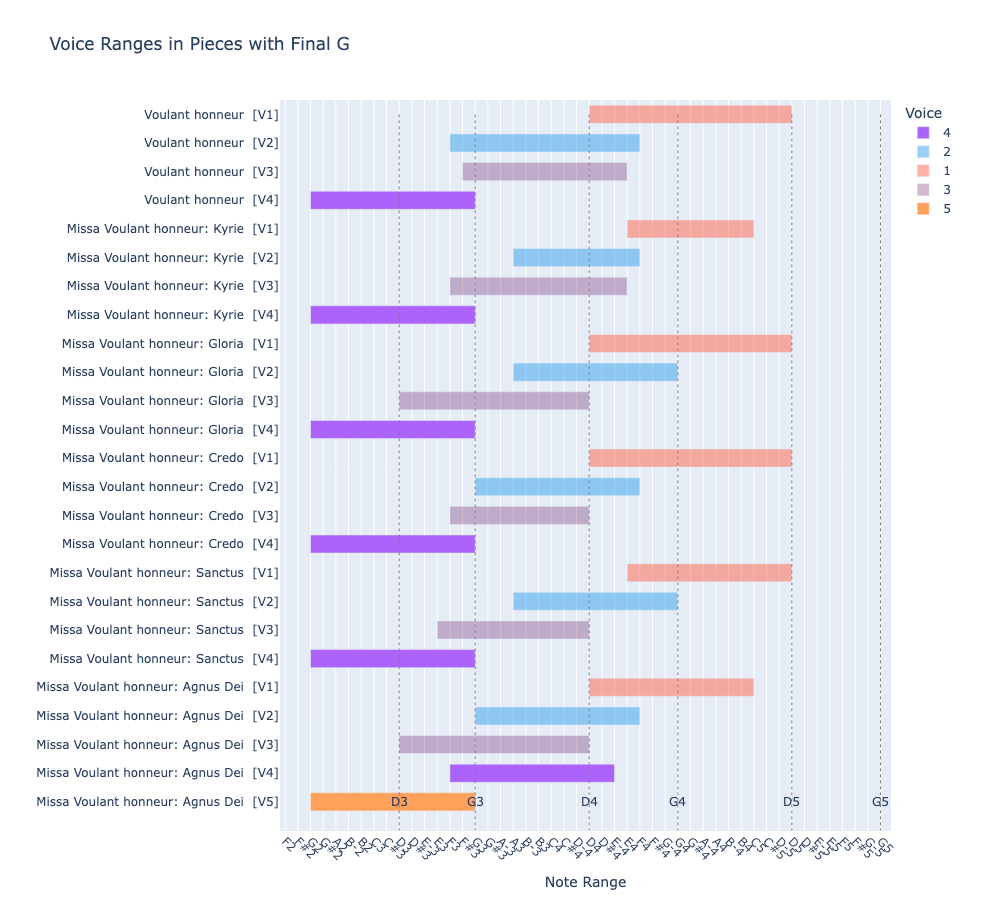

In [17]:
# now the chart
title_sort = ['Voulant honneur', 
              'Missa Voulant honneur: Kyrie', 
              'Missa Voulant honneur: Gloria', 
              'Missa Voulant honneur: Credo', 
              'Missa Voulant honneur: Sanctus', 
              'Missa Voulant honneur: Agnus Dei']


# Set the column as an ordered categorical
corpus_pitch_data['Title'] = pd.Categorical(
    corpus_pitch_data['Title'],
    categories=title_sort,
    ordered=True
)

# Now sort respects that order
corpus_pitch_data.sort_values('Title', inplace=True)
voice_range_chart(corpus_pitch_data, recta_order, top_n=7)

## 4a. Cadences in One Piece

In [7]:
# just one piece to test things out
piece = importScore('https://crimproject.org/mei/CRIM_Model_0012.mei')

cads = piece.cadences()
['Measure', 'Beat', 'Tone', 'CadType',  'CVFs', 'Progress']
cads = cads[['Measure', 'Beat', 'Tone', 'CadType',  'CVFs','Progress']]
cads.reset_index(drop=True)

,Measure,Beat,Tone,CadType,CVFs,Progress
0,2.0000,3.0000,B-,Authentic,tCB,0.0303
1,6.0000,1.0000,D,Authentic,TuCB,0.1010
2,8.0000,3.0000,G,Clausula Vera,tCT,0.1515
3,10.0000,3.0000,G,Authentic,CuTB,0.1919
4,12.0000,3.0000,B-,Authentic,tCB,0.2323
5,16.0000,1.0000,D,Authentic,TuCB,0.3030
6,18.0000,3.0000,G,Clausula Vera,tCT,0.3535
7,20.0000,3.0000,G,Authentic,CuTB,0.3939
8,25.0000,1.0000,B-,Authentic,CuTB,0.4848
9,29.0000,3.0000,A,Phrygian,CTP,0.5758


## 4b.  Cadences in a Corpus

In [11]:
cadences = corpus_cadences(corpus)

In [12]:
cadences_brief = cadences[['Composer', 'Title', 'CadType', 'Tone', 'Progress']].dropna()
cadences_brief.head()

,Composer,Title,CadType,Tone,Progress
Last,,,,,
12.0000,Pierre Sandrin,Voulant honneur,Authentic,B-,0.0303
40.0000,Pierre Sandrin,Voulant honneur,Authentic,D,0.1010
60.0000,Pierre Sandrin,Voulant honneur,Clausula Vera,G,0.1515
76.0000,Pierre Sandrin,Voulant honneur,Authentic,G,0.1919
92.0000,Pierre Sandrin,Voulant honneur,Authentic,B-,0.2323


## 4c.  Radar Plot of Cadences

- Note that we can display the tones in three different possible orderings:  "Thirds", "Fifths", "Diatonic"
- We can also either show _all_ possible tones or limit to only those that are in the data

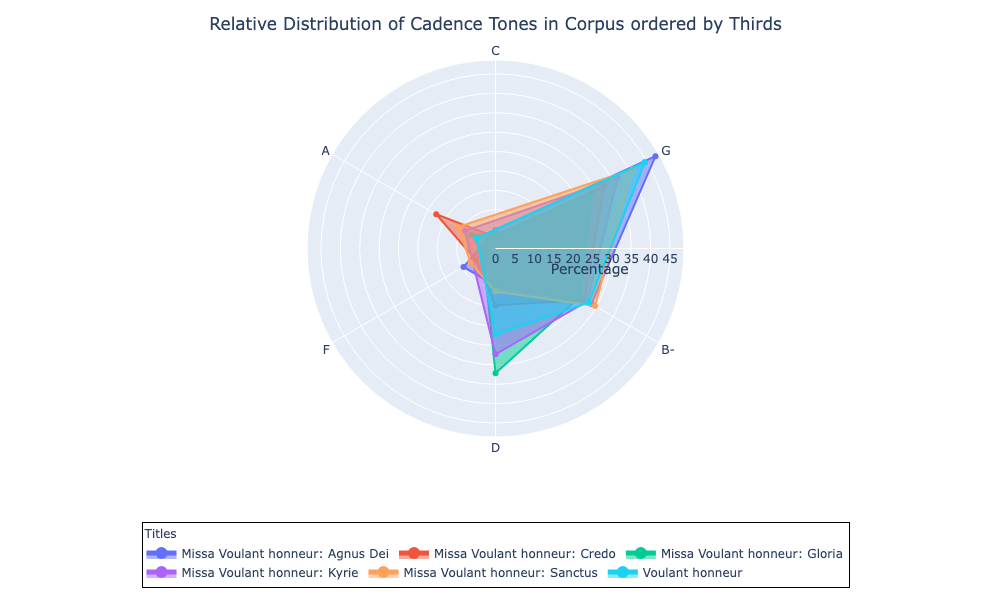

In [21]:
#
tone_order = 'Thirds'
limit_to_active=True
cadence_radar(cadences, tone_ordering=tone_order, limit_to_active=limit_to_active)

## 4d.  Cadence Bar Charts

- This will create a series of bar charts for cadence types and tones in your corpus

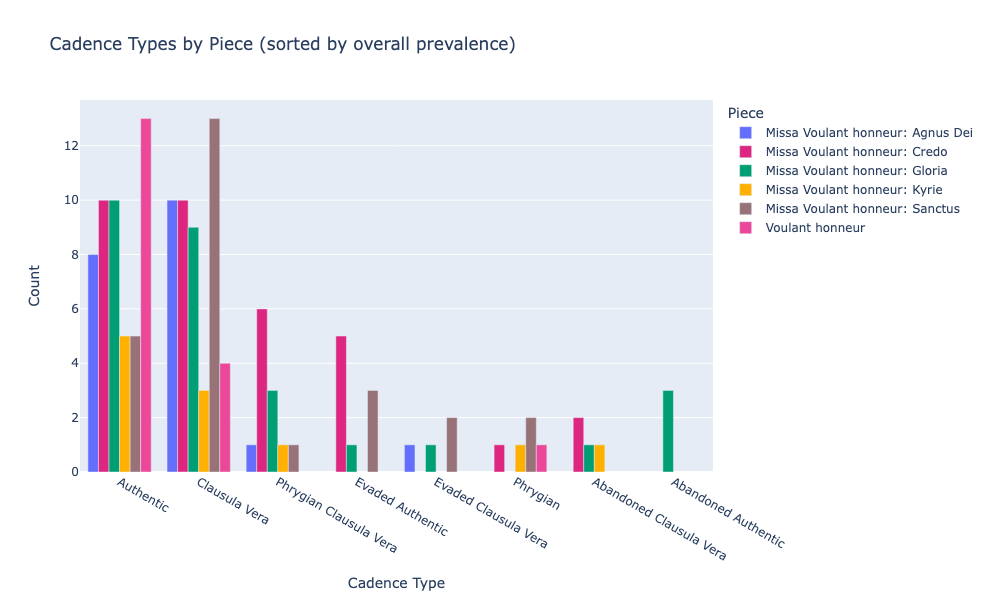

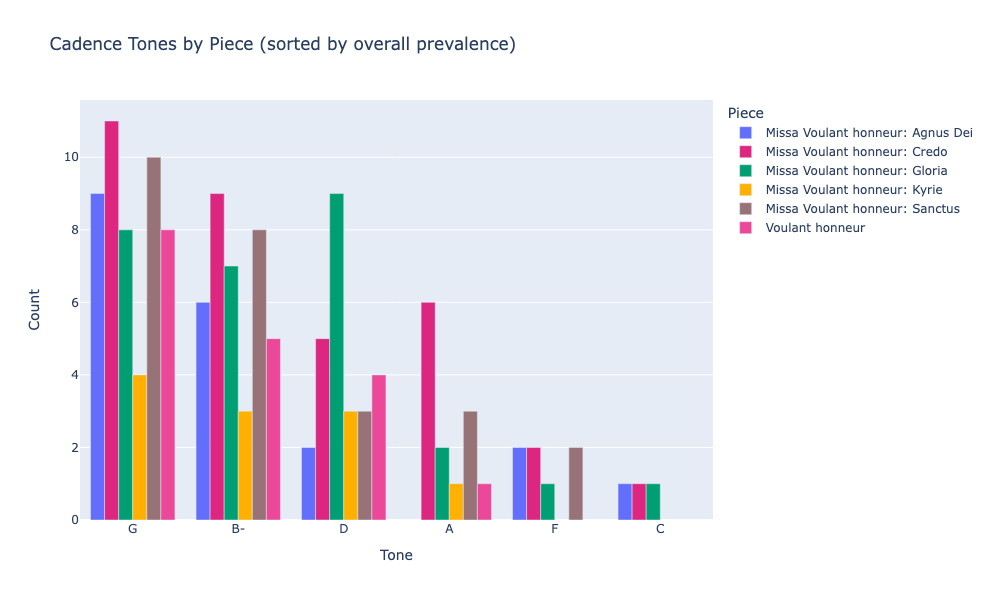


Creating percentage versions...


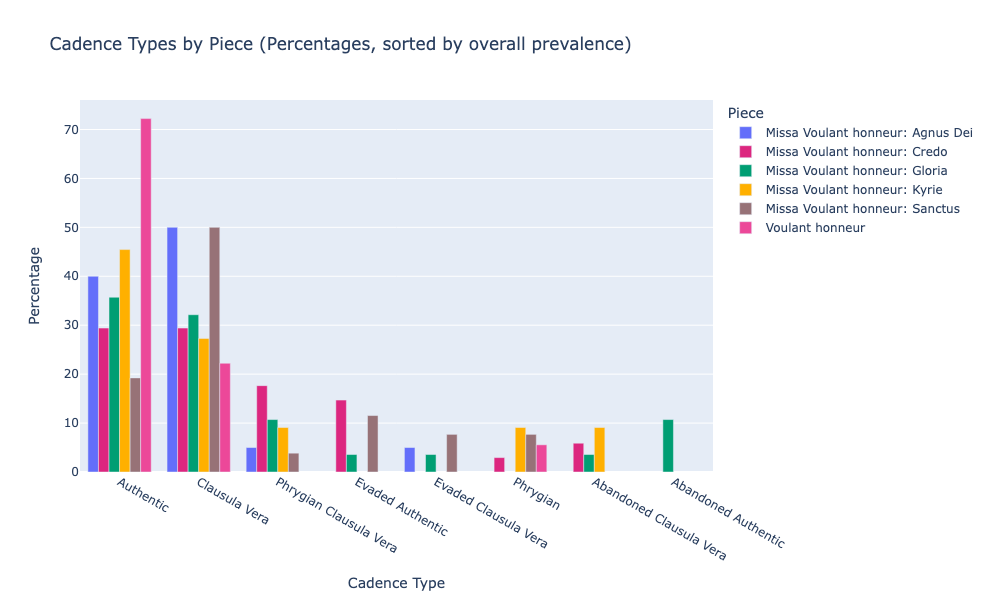

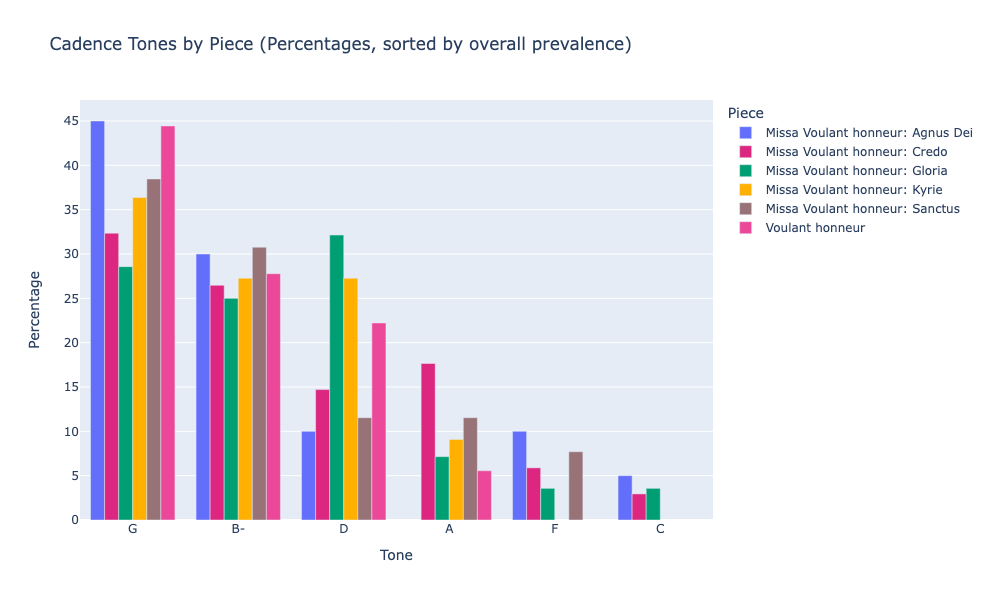

In [22]:
cadence_bar_charts(cadences, cadences_brief, contrasting_colors)

## 4e.  Cadence Tone Scatter Plots

- This creates a single chart showing the proportion of cadences to each tone for each piece in your corpus
- Note that you need to update the 'title sort' data to match the titles in your corpus!


In [23]:
title_sort = ['Voulant honneur', 
              'Missa Voulant honneur: Kyrie', 
              'Missa Voulant honneur: Gloria', 
              'Missa Voulant honneur: Credo', 
              'Missa Voulant honneur: Sanctus', 
              'Missa Voulant honneur: Agnus Dei']

tone_sort = ['G', 'B-', 'D', 'F', 'A', 'C']

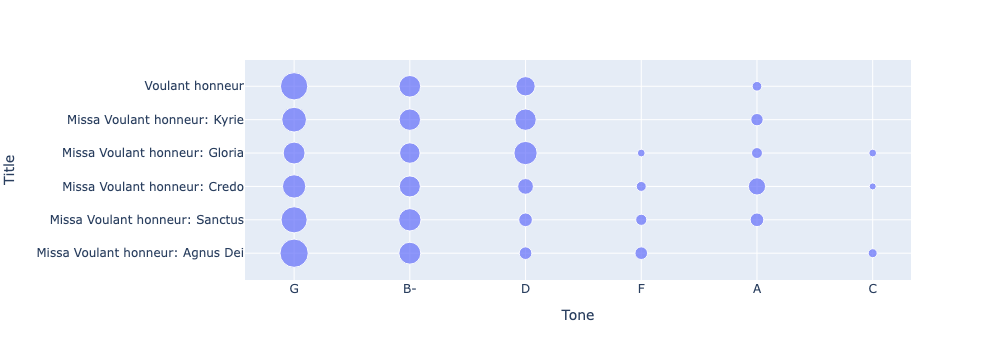

In [26]:
cadence_tone_percent = cadences.groupby(['Tone', 'Title']).size().reset_index(name='Count')

# Calculate % of cadences within each Title
cadence_tone_percent['Percent'] = (
    cadence_tone_percent.groupby('Title')['Count']
    .transform(lambda x: x / x.sum() * 100)
)

cadence_tone_percent['Title'] = pd.Categorical(cadence_tone_percent['Title'], categories=title_sort, ordered=True)

fig = px.scatter(cadence_tone_percent,
                 x='Tone',
                 y='Title',
                 size='Percent',
                 hover_data={'Count': True, 'Percent': ':.1f'})

fig.update_yaxes(categoryorder='array', 
                 categoryarray=title_sort[::-1])
fig.update_xaxes(categoryorder='array', 
                 categoryarray=tone_sort)
fig.show()

In [27]:
cadence_tone_percent

,Tone,Title,Count,Percent
0,A,Missa Voulant honneur: Credo,6,17.6471
1,A,Missa Voulant honneur: Gloria,2,7.1429
2,A,Missa Voulant honneur: Kyrie,1,9.0909
3,A,Missa Voulant honneur: Sanctus,3,11.1111
4,A,Voulant honneur,1,5.5556
5,B-,Missa Voulant honneur: Agnus Dei,6,28.5714
6,B-,Missa Voulant honneur: Credo,9,26.4706
7,B-,Missa Voulant honneur: Gloria,7,25.0000
8,B-,Missa Voulant honneur: Kyrie,3,27.2727
9,B-,Missa Voulant honneur: Sanctus,8,29.6296


In [28]:
# Count then normalize within each piece
cadence_tone_type_percent = (cadences
    .groupby(['Title', 'Tone', 'CadType','CVFs'])
    .size()
    .reset_index(name='Count'))

cadence_tone_type_percent['Pct'] = (cadence_tone_type_percent
    .groupby('Title')['Count']
    .transform(lambda x: x / x.sum() * 100))
cadence_tone_type_percent

,Title,Tone,CadType,CVFs,Count,Pct
0,Missa Voulant honneur: Agnus Dei,B-,Authentic,CuTB,1,5.0000
1,Missa Voulant honneur: Agnus Dei,B-,Authentic,CxSzB,1,5.0000
2,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,CT,1,5.0000
3,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,TC,1,5.0000
4,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,zCT,1,5.0000
...,...,...,...,...,...,...
95,Voulant honneur,B-,Authentic,tCB,4,22.2222
96,Voulant honneur,D,Authentic,TuCB,4,22.2222
97,Voulant honneur,G,Authentic,CTB,2,11.1111
98,Voulant honneur,G,Authentic,CuTB,2,11.1111


In [30]:
def classify(k):
    k_upper = k.upper()          # normalize case
    ci = k_upper.find('C')
    ti = k_upper.find('T')
    
    if ci == -1 and ti == -1:
        return 'other'
    elif ci == -1:
        return 'inverted'
    elif ti == -1:
        return 'normal'
    else:
        return 'normal' if ci < ti else 'inverted'
        
keys = cadence_tone_type_percent['CVFs'].unique()

cadence_type_map = {k: classify(k) for k in keys}

cadence_tone_type_percent['CadClass'] = cadence_tone_type_percent['CVFs'].map(cadence_type_map)
cadence_tone_type_percent

,Title,Tone,CadType,CVFs,Count,Pct,CadClass
0,Missa Voulant honneur: Agnus Dei,B-,Authentic,CuTB,1,5.0000,normal
1,Missa Voulant honneur: Agnus Dei,B-,Authentic,CxSzB,1,5.0000,normal
2,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,CT,1,5.0000,normal
3,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,TC,1,5.0000,inverted
4,Missa Voulant honneur: Agnus Dei,B-,Clausula Vera,zCT,1,5.0000,normal
...,...,...,...,...,...,...,...
95,Voulant honneur,B-,Authentic,tCB,4,22.2222,inverted
96,Voulant honneur,D,Authentic,TuCB,4,22.2222,inverted
97,Voulant honneur,G,Authentic,CTB,2,11.1111,normal
98,Voulant honneur,G,Authentic,CuTB,2,11.1111,normal


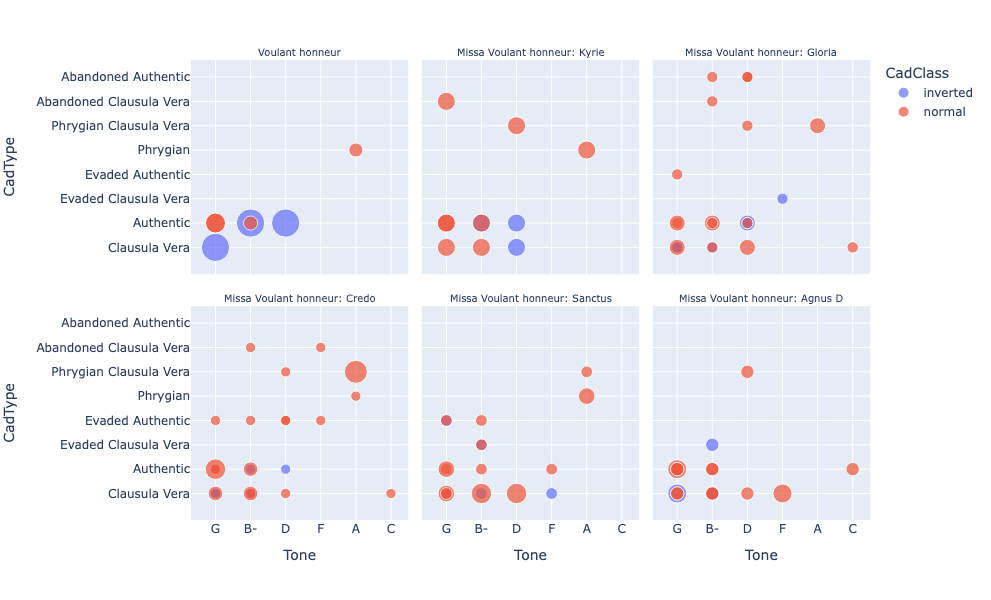

In [31]:
cadence_tone_type_percent['Title'] = pd.Categorical(cadence_tone_type_percent['Title'], 
                                       categories=title_sort, 
                                       ordered=True)

fig = px.scatter(cadence_tone_type_percent.sort_values('Title'),  # sort_values enforces the order
                 x='Tone',
                 y='CadType',
                 size='Pct',
                 color='CadClass',
                 facet_col='Title',
                 facet_col_wrap=3,
                 labels={'Pct': '% of cadences'},
                 height=600)

fig.for_each_annotation(lambda a: a.update(
    text=a.text.split("=")[-1][:30],
    font_size=10
))

for axis in fig.layout:
    if axis.startswith('xaxis'):
        fig.layout[axis].categoryorder = 'array'
        fig.layout[axis].categoryarray = tone_sort

fig.show()

## 5. Ranges and Species 

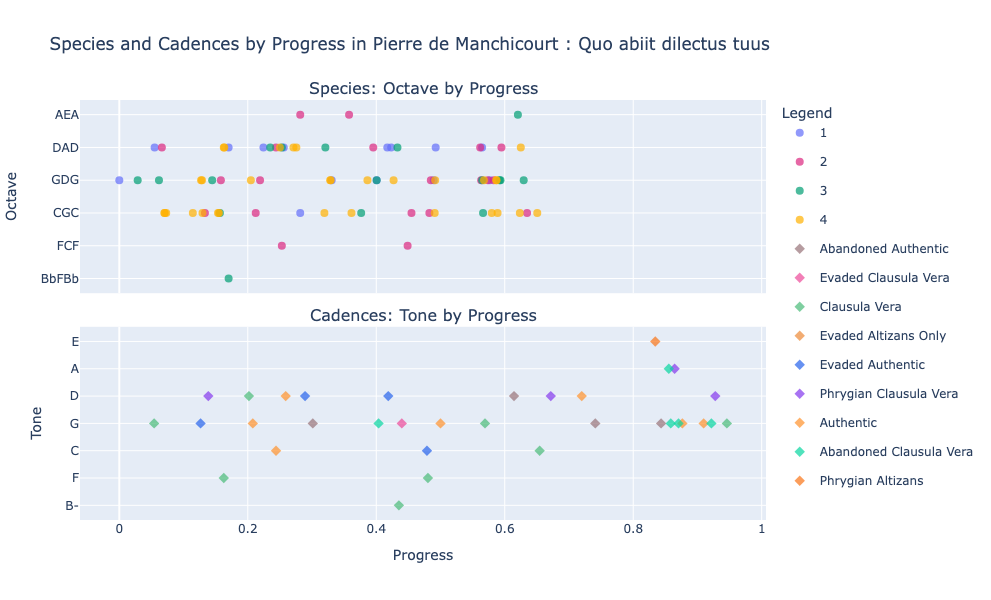

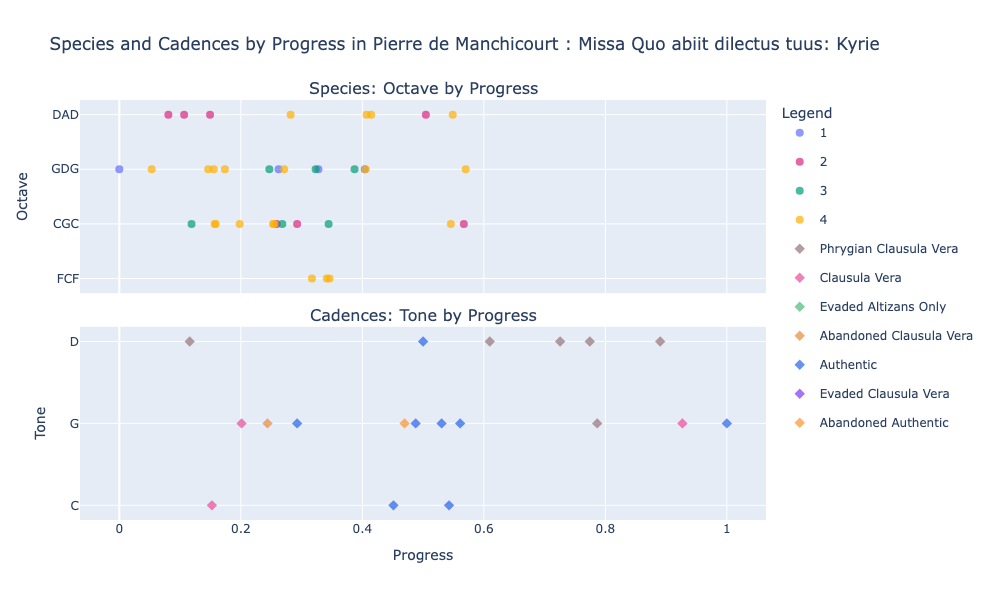

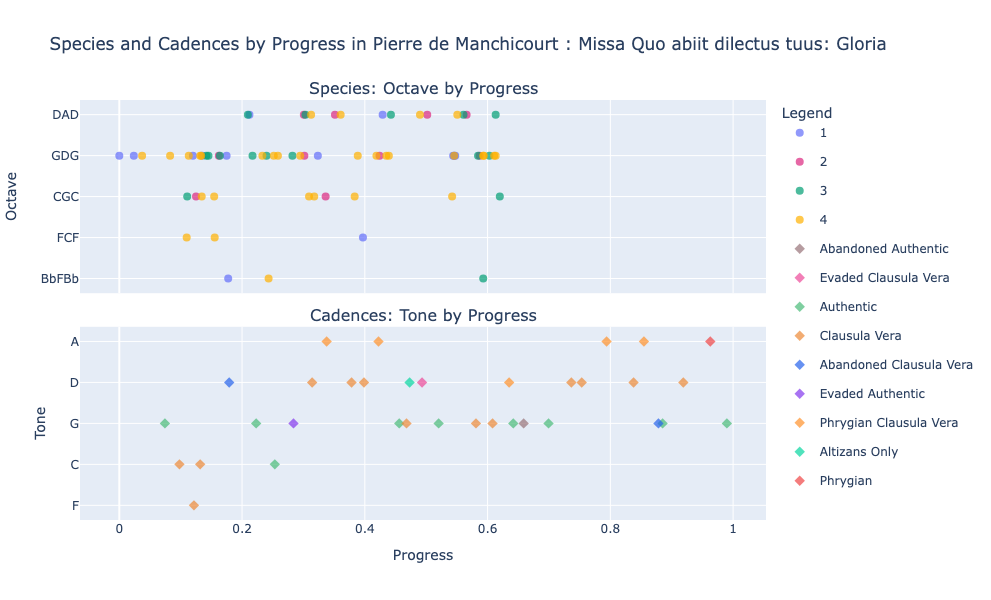

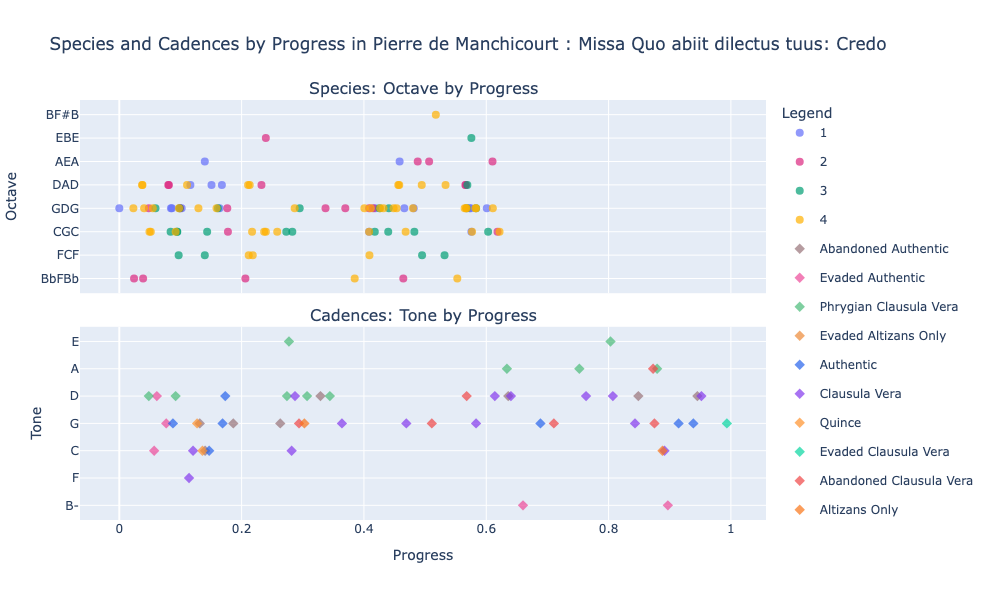

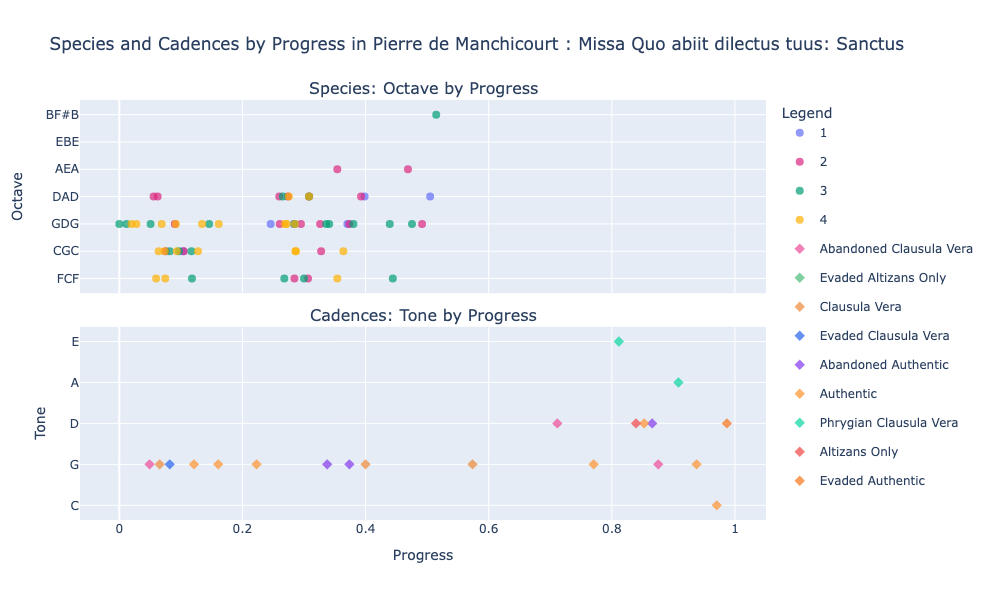

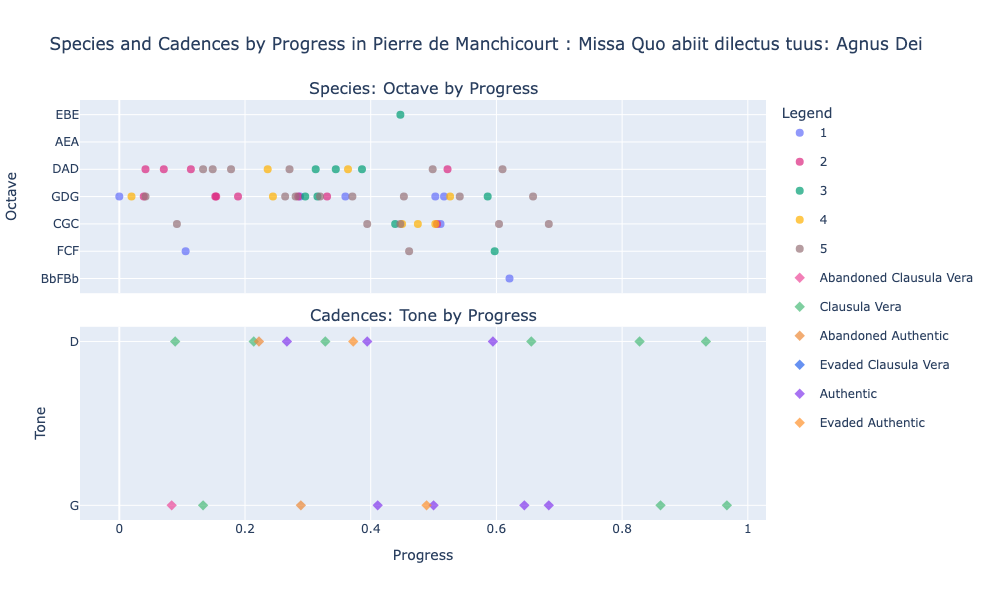

In [20]:
limit_to_main_cadence_types = True

for file in quo_abiit:
    piece = importScore(file)
    # cadences
    cadence_df = piece.cadences()
    cadence_df['Composer'] = piece.metadata['composer'] 
    cadence_df['Title'] = piece.metadata['title']
    selected_types = ['Clausula Vera', 'Authentic', 'Phrygian Clausula Vera', 'Phrygian']
    if limit_to_main_cadence_types:

        cadences_df = cadence_df[cadence_df['CadType'].isin(selected_types)]
    else:
        pass
# 

    # species
    species_df = find_species(piece, limit_to_entries=False, species_intervals = ['5', '-5', '4', '-4'])

    # plot
    plot_species_cadences(species_df, cadence_df, 
                      piece.metadata['composer'], 
                      piece.metadata['title'])